# Tendons Actuators and sensors

In [18]:
import mujoco
import mediapy as media
import numpy as np
import matplotlib.pyplot as plt

""

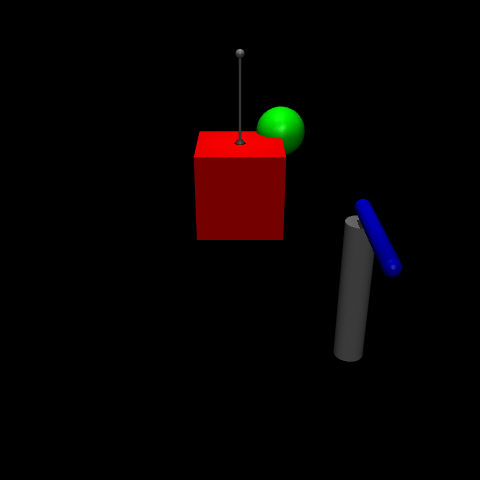

In [46]:
model = mujoco.MjModel.from_xml_path('pinata.xml')
data = mujoco.MjData(model)
height = 480
width = 480

with mujoco.Renderer(model, height, width) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, "fixed")
    media.show_image(renderer.render())

In [47]:
# activate the bat and leave the pinata passive

n_frames = 180
height = 240
width = 320
frames = []
fps = 60
times = []
sensordata = []

# constant actuator signal
mujoco.mj_resetData(model, data)
data.ctrl = 20

# Simulate and display video
with mujoco.Renderer(model, height, width) as renderer:
    for i in range(n_frames):
        while data.time < i/fps:
            mujoco.mj_step(model,data)
            times.append(data.time)
            sensordata.append(data.sensor('accelerometer').data.copy())
        renderer.update_scene(data, "fixed")
        frame = renderer.render()
        frames.append(frame)
    media.show_video(frames, fps=fps)

This browser does not support the video tag.


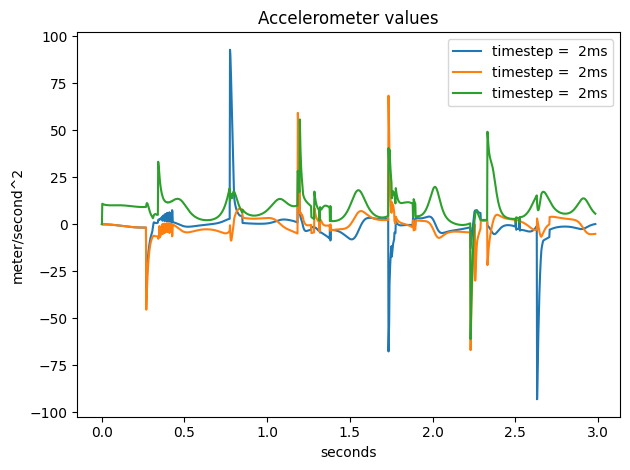

In [15]:
# Plot the accelerometer data

ax = plt.gca()

ax.plot(np.asarray(times), np.asarray(sensordata), label='timestep = {:2.2g}ms'.format(1e3*model.opt.timestep))

# finalize the plot
ax.set_title('Accelerometer values')
ax.set_ylabel('meter/second^2')
ax.set_xlabel('seconds')
ax.legend(frameon=True, loc='upper right')
plt.tight_layout()